In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1. refractive index of Polystyrene - 소스코드와 일치

Sample을 두개의 물질 (PS and Air/Vacuum)으로 구성할 때에는 Bruggeman approximation과 계산 결과가 거의 유사한 Maxwell-Garnett equation을 사용하는데,
MG를 이용한 결과는 소스코드의 결과와 완전히 일치한다. (`_get_n_eff_ps_matrix_mg`로 구현됨)

Bruggeman approximation 또한 본인 모델에 `_get_n_eff_ps_matrix`로 구현되어 있으며, 기본적으로 이 모델을 사용한다.

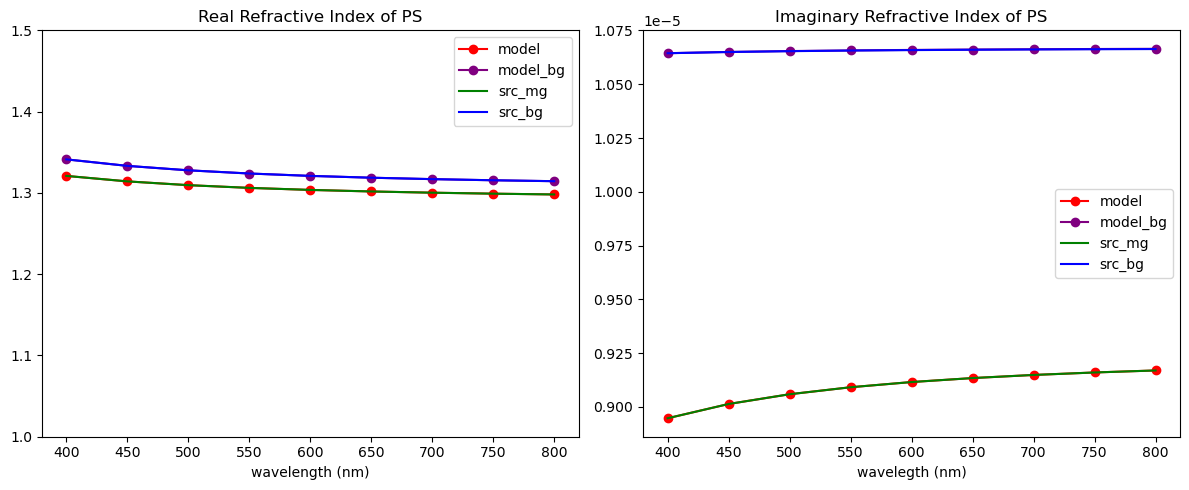

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

model_data = pd.read_csv("diagnostic_table.csv")
model_wvls = model_data["wavelength_nm"]
model_neff_mg_real = model_data["n_eff_mg_real"]
model_neff_mg_imag = model_data["n_eff_mg_imag"]
model_neff_bg_real = model_data["n_eff_bg_real"]
model_neff_bg_imag = model_data["n_eff_bg_imag"]

src_neff_data = pd.read_csv("data/src_neff.csv")
src_wvls = src_neff_data["wvls"]
src_neff_mg_real = src_neff_data["neff_mg_real"]
src_neff_mg_imag = src_neff_data["neff_mg_imag"]
src_neff_bg_real = src_neff_data["neff_bg_real"]
src_neff_bg_imag = src_neff_data["neff_bg_imag"]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(model_wvls, model_neff_mg_real, color='red', label="model", marker= "o")
axes[0].plot(model_wvls, model_neff_bg_real, color='purple', label="model_bg", marker= "o")
axes[0].plot(src_wvls, src_neff_mg_real, color='green', label="src_mg")
axes[0].plot(src_wvls, src_neff_bg_real, color='blue', label="src_bg")
axes[0].set_title('Real Refractive Index of PS')
axes[0].set_xlabel('wavelength (nm)')
axes[0].legend()
axes[0].set_ylim([1, 1.5])

axes[1].plot(model_wvls, model_neff_mg_imag, color='red', label="model", marker= "o")
axes[1].plot(model_wvls, model_neff_bg_imag, color='purple', label="model_bg", marker= "o")
axes[1].plot(src_wvls, src_neff_mg_imag, color='green', label="src_mg")
axes[1].plot(src_wvls, src_neff_bg_imag, color='blue', label="src_bg")
axes[1].set_title('Imaginary Refractive Index of PS')
axes[1].set_xlabel('wavelegth (nm)')
axes[1].legend()
axes[0].set_ylim([1., 1.5])

plt.tight_layout()
plt.show()


### 2. Structure Factor 비교 - 소스코드와 일치

monodisperse한 필름에 대해서 Percus-Yevick equation을 통해 Structure Factor를 계산한다.

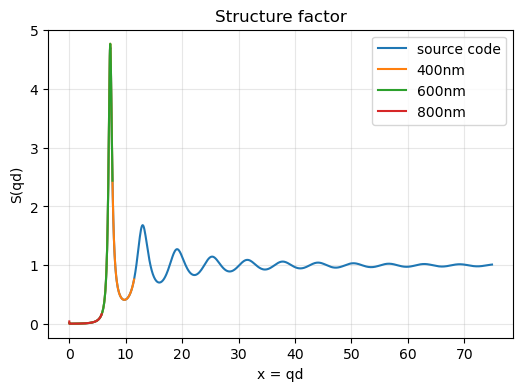

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

d = 0.138 * 2

model_data = pd.read_csv("data/model_structure.csv")
model_q400 = model_data['q400']
model_S_q400 = model_data['S_q400']
model_q500 = model_data['q500']
model_S_q500 = model_data['S_q500']
model_q600 = model_data['q600']
model_S_q600 = model_data['S_q600']
model_q700 = model_data['q700']
model_S_q700 = model_data['S_q700']
model_q800 = model_data['q800']
model_S_q800 = model_data['S_q800']

src_struc_data = pd.read_csv("data/src_structure.csv")
src_qd = src_struc_data["qd"]
src_S_qd = src_struc_data["s_data"]

plt.figure(figsize=(6, 4))
plt.plot(src_qd, src_S_qd, label="source code")
plt.plot(model_q400*d, model_S_q400, label="400nm")   
plt.plot(model_q600*d, model_S_q600, label="600nm")  
plt.plot(model_q800*d, model_S_q800, label="800nm")  
plt.xlabel("x = qd")
plt.ylabel("S(qd)")
plt.title("Structure factor")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 3. Scattering / Absorbing Coefficient / Asymmetry parameter / transport length - 소스코드와 일치 
Scattering coefficient($\mu_s$)는 두 종류가 존재한다.
- $C_{sca}^{sample}$을 이용한 bulk 내에서의 산란 계수 --> n_sample(n_eff) 사용
- $C_{sca}^{Mie}$을 이용한 fine roughness에 의한 surface에서의 산란계수 --> n_matrix(vacuum) 사용
  
1) $\mu_s^{sample}$
- number density와 $C^{sample}_{sca}$의 곱이다
- number density가 이상이 없으므로 $C^{sample}_{sca}$ value 또한 소스코드와 일치한다.
- $C_{sca}^{sample} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}S(q)sinθdθ$이므로, 본인의 모델의 `_get_mie_absorbing` 함수가 소스코드와 동일한 결과를 반환함을 알 수 있다.

2) $\mu_s^{Mie}$
- 본 모델은 소스코드와 다른 값을 반환했다.
- 소스코드는 Mie scattering 계산 과정에서 주변 물질의 굴절률로 matrix(vacuum)의 굴절률을 사용했으나, 본 모델은 sample의 유효 굴절률을 사용하고 있었음
- 아래와 같이 수정하여 소스코드와 반환 결과를 일치시켰다.
  
```bash
# 수정 전 : n_eff_complex=n_eff_complex 
diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_host_complex=n_eff_complex,
    theta_array=theta_array,
    backend="internal",
)

# 수정 버전: n_eff_complex=n_matrix

diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_host_complex=n_matrix,
    theta_array=theta_array,
    backend="internal",
)
```


Assymetry parameter 또한 일치한다는 것은 소스코드와 모델의 transport length 차이가 없음을 의미하며 Asymmetry parameter 계산 과정에 존재하는 theta pdf도 동일하다는 것을 의미한다.

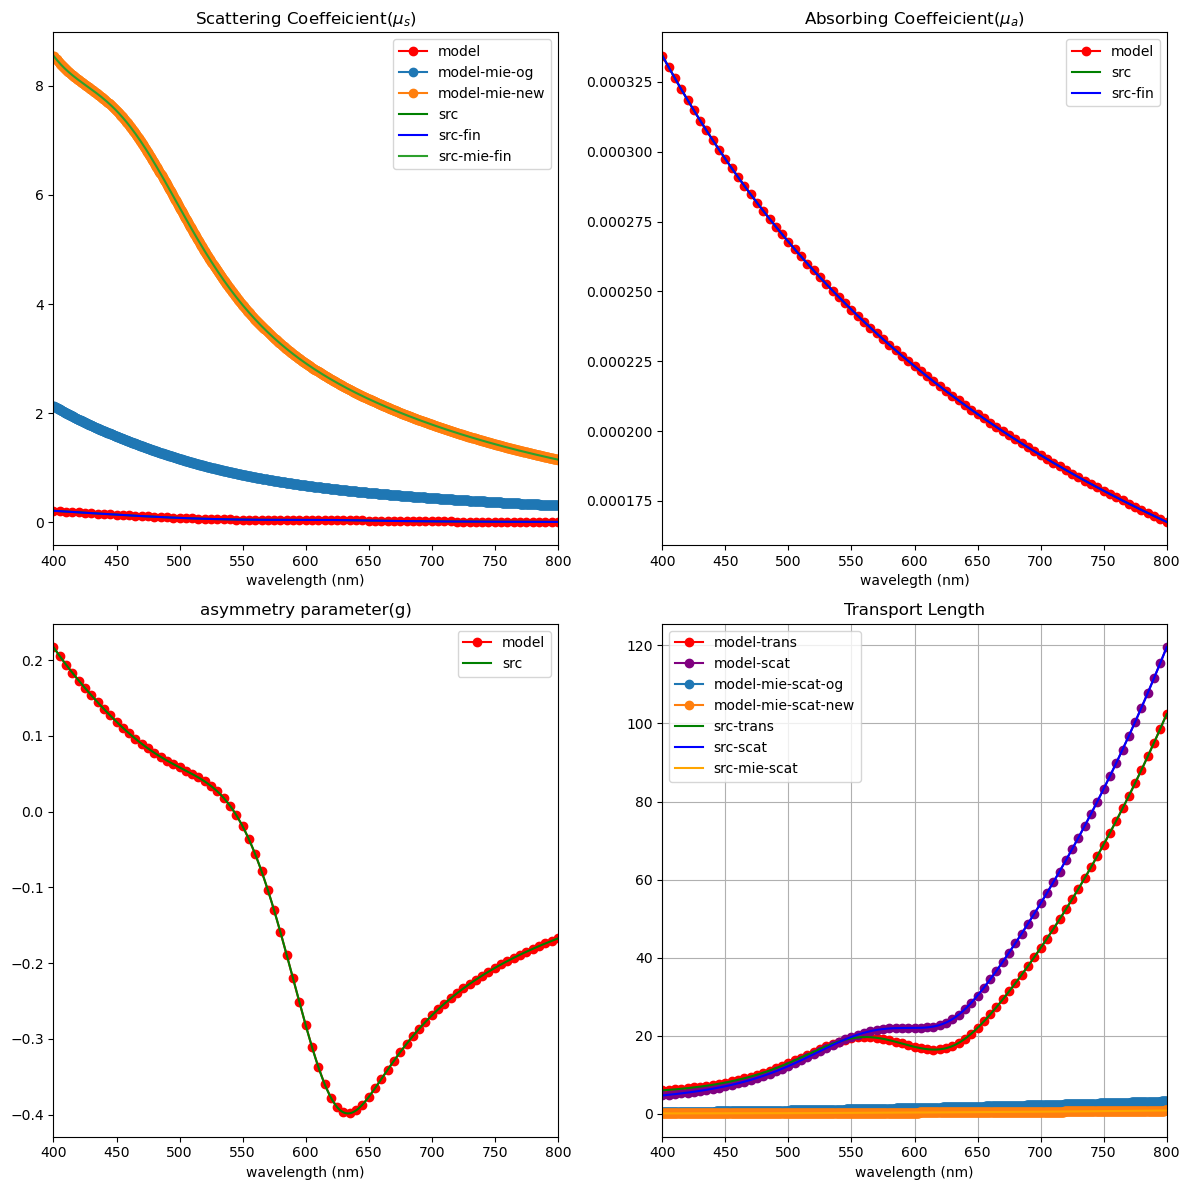

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_data = pd.read_csv("diagnostic_table.csv")
model_wvls = model_data["wavelength_nm"]
model_l_scat = model_data["l_scat_sample_um"]
model_mu_scat = 1 / model_l_scat
model_mu_abs = model_data["mu_a_bg"]
model_l_star = model_data["l_transport_um"]
model_g = model_data["g"]

model_csca_data = np.load("data/model_phase.npz")
model_csca_wvls = model_csca_data["wvls"]
model_csca = model_csca_data["csca"]

model_mie_data = pd.read_csv("data/model_mu_mie.csv")
model_mie_wvls = model_mie_data["wvls"]
model_mie_mu_scat= model_mie_data["mu_scat_mie"]

model_mie_new_data = pd.read_csv("data/model_mu_mie_new.csv")
model_mie_new_wvls = model_mie_new_data["wvls"]
model_mie_new_mu_scat= model_mie_new_data["mu_scat_mie"]

src_mu_data = np.load("data/src_mu.npz")
src_wvls = src_mu_data["wvls"]
src_mu_scat = src_mu_data["mu_scat"]
src_mu_abs = src_mu_data["mu_abs"]
src_csca_sample = src_mu_data["csca_sample"]
src_phase = src_mu_data["phase"]

src_mu_data_fin = np.load("data/src_mu_final.npz")
src_wvls_fin = src_mu_data_fin["wvls"]
src_mu_scat_fin = src_mu_data_fin["mu_scat"][:,0]
src_mu_scat_mie_fin = src_mu_data_fin["mu_scat"][:,1]
src_mu_abs_fin = src_mu_data_fin["mu_abs"]
src_csca_sample_fin = src_mu_data_fin["csca_sample"]
src_phase_fin = src_mu_data_fin["phase"]
src_phase_prob = src_mu_data_fin["prob"]
src_phase_prob_norm = src_mu_data_fin["prob_norm"]

src_transport_data = pd.read_csv("data/src_transport_length.csv")
src_transport_wvls = src_transport_data["wvls"]
src_l_star = src_transport_data["l_star"]
src_g = src_transport_data["g"]


fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].plot(model_wvls, model_mu_scat, color='red', label="model", marker= "o")
axes[0,0].plot(model_mie_wvls*1000, model_mie_mu_scat, label="model-mie-og", marker= "o")
axes[0,0].plot(model_mie_new_wvls*1000, model_mie_new_mu_scat, label="model-mie-new", marker= "o")
axes[0,0].plot(src_wvls, src_mu_scat, color='green', label="src")
axes[0,0].plot(src_wvls_fin, src_mu_scat_fin, color='blue', label="src-fin")
axes[0,0].plot(src_wvls_fin, src_mu_scat_mie_fin, label="src-mie-fin")
axes[0,0].set_title(r'Scattering Coeffeicient($\mu_{s}$)')
axes[0,0].set_xlabel('wavelength (nm)')
axes[0,0].legend()
axes[0,0].set_xlim(400, 800)


axes[0,1].plot(model_wvls, model_mu_abs, color='red', label="model", marker= "o")
axes[0,1].plot(src_wvls, src_mu_abs, color='green', label="src")
axes[0,1].plot(src_wvls_fin, src_mu_abs_fin, color='blue', label="src-fin")
axes[0,1].set_title(r'Absorbing Coeffeicient($\mu_{a}$)')
axes[0,1].set_xlabel('wavelegth (nm)')
axes[0,1].legend()
axes[0,1].set_xlim(400, 800)

axes[1,0].plot(model_wvls, model_g, color='red', label="model", marker= "o")
axes[1,0].plot(src_transport_wvls, src_g, color='green', label="src")
axes[1,0].set_title('asymmetry parameter(g)')
axes[1,0].set_xlabel('wavelength (nm)')
axes[1,0].legend()
axes[1,0].set_xlim(400, 800)

axes[1,1].plot(model_wvls, model_l_star, color='red', label="model-trans", marker= "o")
axes[1,1].plot(model_wvls, model_l_scat, color='purple', label="model-scat", marker= "o")
axes[1,1].plot(model_mie_wvls*1000, 1/model_mie_mu_scat, label="model-mie-scat-og", marker= "o")
axes[1,1].plot(model_mie_new_wvls*1000, 1/model_mie_new_mu_scat, label="model-mie-scat-new", marker= "o")
axes[1,1].plot(src_transport_wvls, src_l_star/1000, color='green', label="src-trans")
axes[1,1].plot(src_transport_wvls, 1/src_mu_scat, color='blue', label="src-scat")
axes[1,1].plot(src_wvls_fin, 1/src_mu_scat_mie_fin, color='orange', label="src-mie-scat")
axes[1,1].set_title('Transport Length')
axes[1,1].set_xlabel('wavelength (nm)')
axes[1,1].legend()
axes[1,1].set_xlim(400, 800)
axes[1,1].grid()

plt.tight_layout()
plt.show()

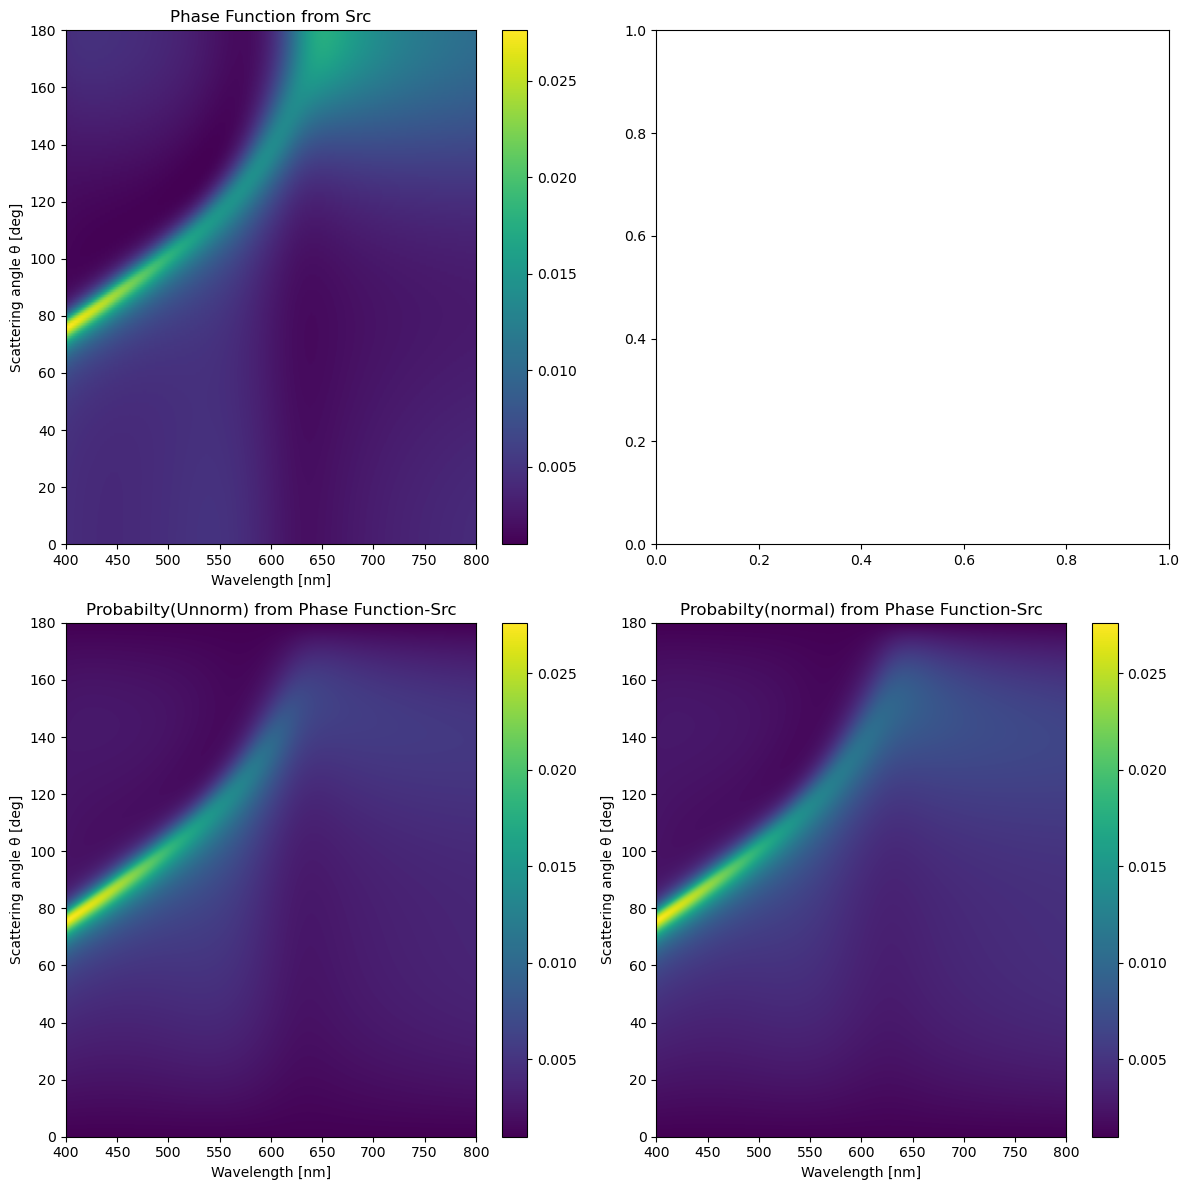

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

im1 = axes[0,0].imshow(src_phase.T, extent=[400, 800, 0 , 180],
    aspect="auto", origin="lower")
axes[0,0].set_xlabel("Wavelength [nm]")
axes[0,0].set_ylabel("Scattering angle θ [deg]")
axes[0,0].set_title("Phase Function from Src")
fig.colorbar(im1, ax=axes[0,0])

'''im2 = axes[0,1].imshow(src_phase.T - src_phase_fin.T, extent=[400, 800, 0 , 180],
    aspect="auto", origin="lower", vmin=-0.0025, vmax=0.0025)
axes[0,1].set_xlabel("Wavelength [nm]")
axes[0,1].set_ylabel("Scattering angle θ [deg]")
axes[0,1].set_title("Difference between src, src-final")
fig.colorbar(im2, ax=axes[0,1])'''

im3 = axes[1,0].imshow(src_phase_prob.T, extent=[400, 800, 0 , 180],
    aspect="auto", origin="lower")
axes[1,0].set_xlabel("Wavelength [nm]")
axes[1,0].set_ylabel("Scattering angle θ [deg]")
axes[1,0].set_title("Probabilty(Unnorm) from Phase Function-Src")
fig.colorbar(im1, ax=axes[1,0])

im4 = axes[1,1].imshow(src_phase_prob_norm.T, extent=[400, 800, 0 , 180],
    aspect="auto", origin="lower")
axes[1,1].set_xlabel("Wavelength [nm]")
axes[1,1].set_ylabel("Scattering angle θ [deg]")
axes[1,1].set_title("Probabilty(normal) from Phase Function-Src")
fig.colorbar(im1, ax=axes[1,1])

plt.tight_layout()
plt.show()

## 5. $\theta_a$ sampling via Coarse Roughness

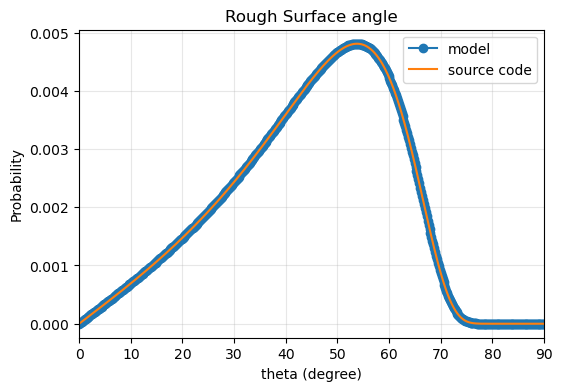

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_theta_data = pd.read_csv("data/model_theta_a.csv")
model_theta = model_theta_data["theta_a"]
model_prob_a = model_theta_data["prob"]

src_theta_data = pd.read_csv("data/src_theta_a.csv")
src_theta = src_theta_data["theta_a"]
src_p_theta = src_theta_data["p_theta"]
src_prob_a = src_theta_data["prob"]

plt.figure(figsize=(6, 4))
plt.plot(np.degrees(model_theta), model_prob_a, label="model", marker="o")
plt.plot(np.degrees(src_theta), src_prob_a, label="source code")
plt.xlabel("theta (degree)")
plt.ylabel("Probability")
plt.title("Rough Surface angle")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 90)
plt.show()

(200000,)


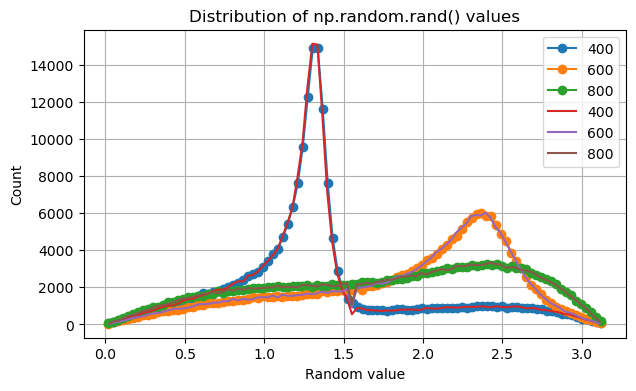

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def vis_histogram(data, bins):
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    #return np.degrees(bin_centers), counts
    return bin_centers, counts

model_cdf_data = pd.read_csv("data/model_cdf_val.csv")
model_scat400 = model_cdf_data["scat400"]
model_scat500 = model_cdf_data["scat500"]
model_scat600 = model_cdf_data["scat600"]
model_scat700 = model_cdf_data["scat700"]
model_scat800 = model_cdf_data["scat800"]

src_cdf_data = pd.read_csv("data/src_cdf_val.csv")
src_scat400 = src_cdf_data["scat400"]
src_scat500 = src_cdf_data["scat500"]
src_scat600 = src_cdf_data["scat600"]
src_scat700 = src_cdf_data["scat700"]
src_scat800 = src_cdf_data["scat800"]

bins = 100

model_x400, model_count400 = vis_histogram(model_scat400, bins)
model_x500, model_count500 = vis_histogram(model_scat500, bins)
model_x600, model_count600 = vis_histogram(model_scat600, bins)
model_x700, model_count700 = vis_histogram(model_scat700, bins)
model_x800, model_count800 = vis_histogram(model_scat800, bins)

src_x400, src_count400 = vis_histogram(src_scat400, bins)
src_x500, src_count500 = vis_histogram(src_scat500, bins)
src_x600, src_count600 = vis_histogram(src_scat600, bins)
src_x700, src_count700 = vis_histogram(src_scat700, bins)
src_x800, src_count800 = vis_histogram(src_scat800, bins)

plt.figure(figsize=(7, 4))
plt.plot(model_x400, model_count400, label="400", marker= "o")
plt.plot(model_x600, model_count600, label="600", marker= "o")
plt.plot(model_x800, model_count800, label="800", marker= "o")
plt.plot(src_x400, src_count400, label="400")
plt.plot(src_x600, src_count600, label="600")
plt.plot(src_x800, src_count800, label="800")

plt.xlabel("Random value")
plt.ylabel("Count")
plt.title("Distribution of np.random.rand() values")
plt.grid(True)
plt.legend()
plt.show()

## 논문, 레퍼런스 photon tracking 프로세스 차이



### Fresnel Reflection

본 모델은 Unpolarized form으로 Fresnel reflection을 계산하나, 소스코드(`model.fresnel_reflection`)는 편광에 따라 `R_s, R_p`를 반환한다. 

허나, `(R_s + R_p) / 2`의 값은 Fresnel reflection과 동일하다

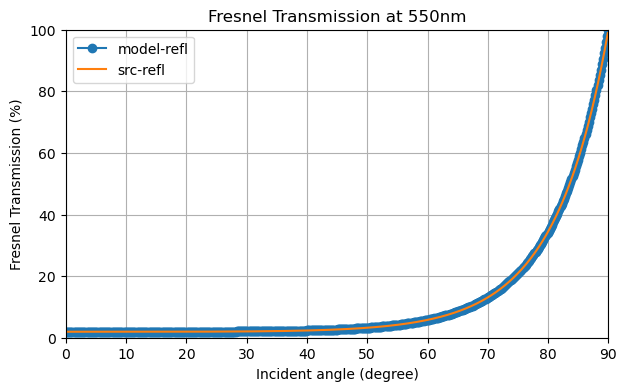

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model_fresnel_data = pd.read_csv("data/model_fresnel.csv")
model_theta = model_fresnel_data["theta"]
model_fresnel_refl = model_fresnel_data["fresnel_refl"]

src_fresnel_data = pd.read_csv("data/src_fresnel.csv")
src_theta = src_fresnel_data["theta"]
src_fresnel_refl = src_fresnel_data["fresnel_refl"]

plt.figure(figsize=(7, 4))
plt.plot(np.degrees(model_theta), model_fresnel_refl*100, label="model-refl", marker="o")
plt.plot(src_theta, src_fresnel_refl*100, label="src-refl")

plt.xlabel("Incident angle (degree)")
plt.ylabel("Fresnel Transmission (%)")
plt.title("Fresnel Transmission at 550nm")
plt.grid(True)
plt.legend()
plt.xlim(0, 90)
plt.ylim(0, 100)
plt.show()